<a href="https://colab.research.google.com/github/IshitaSharma009/ML/blob/Feature-Engineering/Function_Transfrom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle
!chmod 600 /root/.kaggle/kaggle.json

In [2]:
!kaggle datasets download shuofxz/titanic-machine-learning-from-disaster

Dataset URL: https://www.kaggle.com/datasets/shuofxz/titanic-machine-learning-from-disaster
License(s): DbCL-1.0
  0% 0.00/33.1k [00:00<?, ?B/s]
100% 33.1k/33.1k [00:00<00:00, 58.2MB/s]


In [3]:
import zipfile
zip_ref=zipfile.ZipFile('titanic-machine-learning-from-disaster.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [4]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer



In [5]:
df=pd.read_csv('train.csv',usecols=('Age','Fare','Survived'))

In [6]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

<ipython-input-7-694922604>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [8]:
df['Age'].isnull().sum()

np.int64(0)

In [9]:
x=df.iloc[:,1:3]
y=df.iloc[:,0]

In [10]:
x.head()

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

Text(0.5, 1.0, 'Age QQ plot')

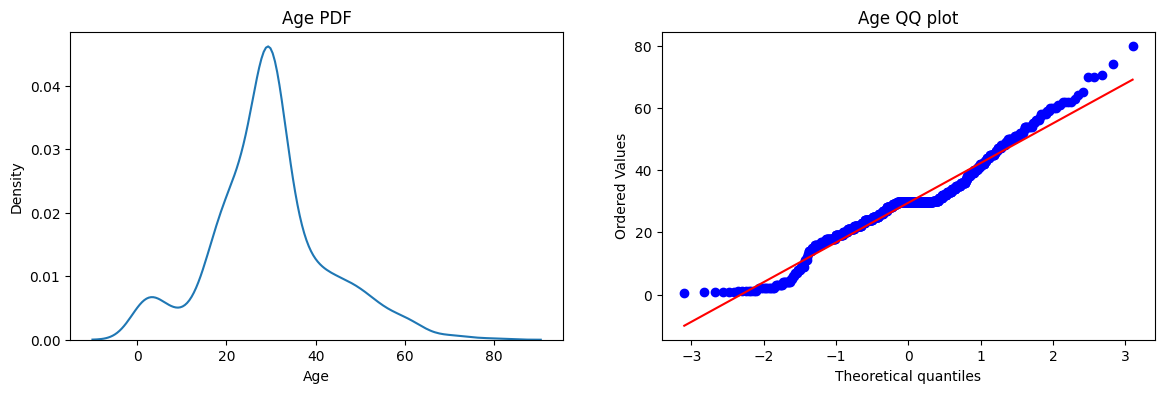

In [12]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.kdeplot(x_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(x_train['Age'],dist='norm',plot=plt)
plt.title('Age QQ plot')

Text(0.5, 1.0, 'Fare QQ plot')

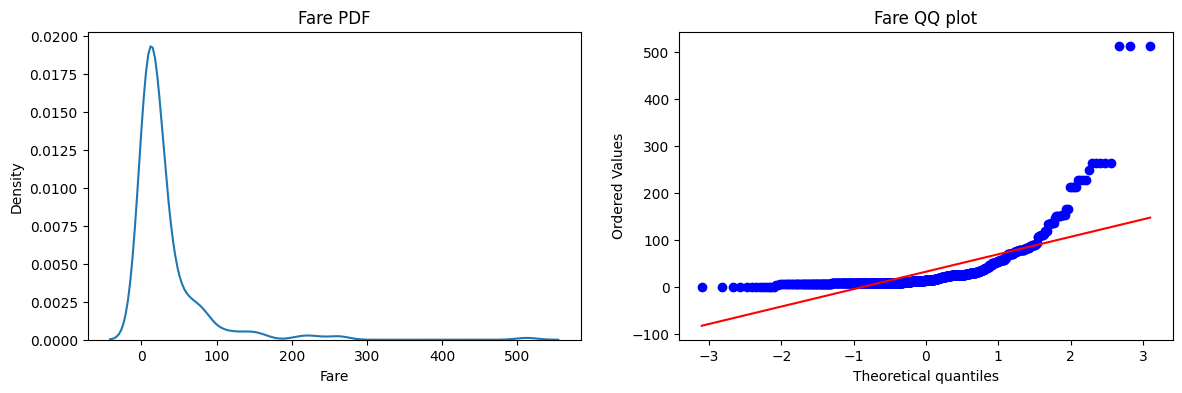

In [13]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.kdeplot(x_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(x_train['Fare'],dist='norm',plot=plt)
plt.title('Fare QQ plot')

In [14]:
clf1=DecisionTreeClassifier()
clf2=LogisticRegression()

clf1.fit(x_train,y_train)
clf2.fit(x_train,y_train)

y_pred1=clf1.predict(x_test)
y_pred2=clf2.predict(x_test)

print("Accuracy DTC:",accuracy_score(y_pred1,y_test))
print("Accuracy LD:",accuracy_score(y_pred2,y_test))

Accuracy DTC: 0.6815642458100558
Accuracy LD: 0.6480446927374302


In [32]:
def apply_transfrom(transform):
    x_new = df.iloc[:,1:3]
    y_new = df.iloc[:,0]

    trf=ColumnTransformer([
    ('log',FunctionTransformer(transform),['Fare'])

    ],remainder='passthrough')

    x_transformed=trf.fit_transform(x_new)

    clf=LogisticRegression()

    clf.fit(x_transformed,y_new)

    print("accuracy",np.mean(cross_val_score(clf,x_transformed,y_new,scoring='accuracy',cv=10)))


    plt.figure(figsize=(14,4))
    plt.subplot(121)

    stats.probplot(x_new['Fare'],dist='norm',plot=plt)
    plt.title('Fare before Transformation')

    plt.subplot(122)

    stats.probplot(x_transformed[:,0],dist='norm',plot=plt)
    plt.title('Fare after Transformation')

    plt.show


accuracy 0.6712609238451936


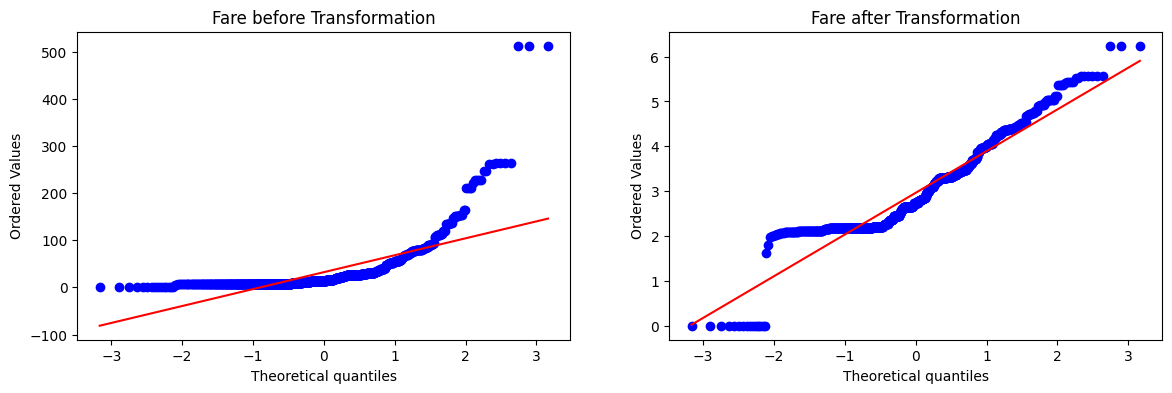

In [40]:
apply_transfrom(np.log1p)

In [44]:
def apply_transfrom(transform):
    x_new = df.iloc[:,1:3]
    y_new = df.iloc[:,0]

    trf=ColumnTransformer([
    ('log',FunctionTransformer(transform),['Age'])

    ],remainder='passthrough')

    x_transformed=trf.fit_transform(x_new)

    clf=LogisticRegression()

    clf.fit(x_transformed,y_new)

    print("accuracy",np.mean(cross_val_score(clf,x_transformed,y_new,scoring='accuracy',cv=10)))


    plt.figure(figsize=(14,4))
    plt.subplot(121)

    stats.probplot(x_new['Age'],dist='norm',plot=plt)
    plt.title('Age before Transformation')

    plt.subplot(122)

    stats.probplot(x_transformed[:,0],dist='norm',plot=plt)
    plt.title('Age after Transformation')

    plt.show


accuracy 0.657752808988764


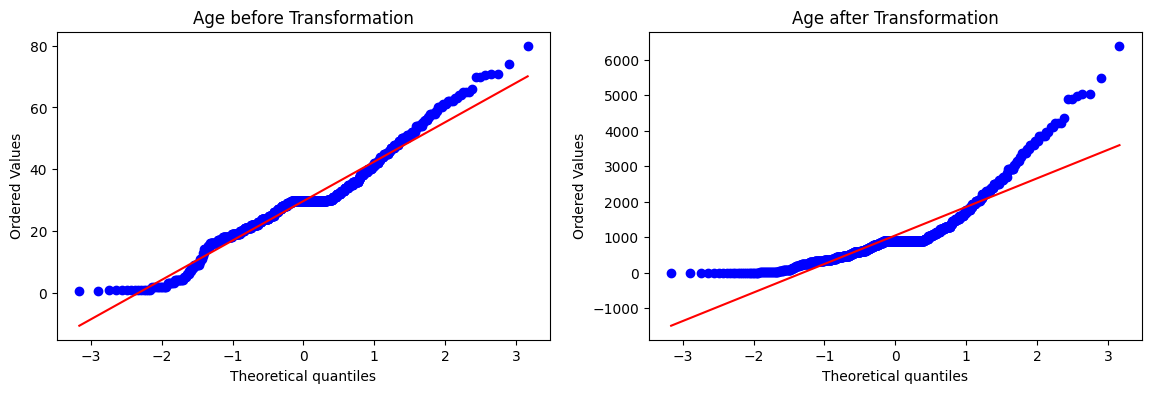

In [53]:
apply_transfrom(lambda x:x**2)

# **so basicallly this how we can check whats working for us**
